<a href="https://colab.research.google.com/github/anix07/STOCK-PRICE-DATA-/blob/main/stock_price_data_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os, random, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import sklearn
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dropout, Dense, Input
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Fix random seeds for reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

# Print software versions for reproducibility record
print(f"Python packages used in this run:")
print(f"  numpy       : {np.__version__}")
print(f"  pandas      : {pd.__version__}")
print(f"  tensorflow  : {tf.__version__}")
print(f"  scikit-learn: {sklearn.__version__}")
print(f"  matplotlib  : {plt.matplotlib.__version__}")
print(f"  random seed : {SEED}")

Python packages used in this run:
  numpy       : 2.0.2
  pandas      : 2.2.2
  tensorflow  : 2.20.0
  scikit-learn: 1.6.1
  matplotlib  : 3.10.0
  random seed : 42


In [2]:
from google.colab import files
uploaded = files.upload()

# Get the actual filename that was uploaded
csv_filename = list(uploaded.keys())[0]
print(f"\nUploaded file: {csv_filename}")

Saving Stock_Price_Data_(3921) (1).csv to Stock_Price_Data_(3921) (1).csv

Uploaded file: Stock_Price_Data_(3921) (1).csv


In [3]:
df = pd.read_csv(csv_filename)
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df = df.sort_values('Date').reset_index(drop=True)

print("Dataset overview")
print(f"  Shape         : {df.shape}")
print(f"  Date range    : {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"  Missing values: {df.isnull().sum().sum()}")
print()
print("Summary statistics:")
display(df.describe())

Dataset overview
  Shape         : (9909, 7)
  Date range    : 1980-12-12 to 2020-04-01
  Missing values: 0

Summary statistics:


,Date,Open,High,Low,Close,Adj Close,Volume
count,9909,9909.000000,9909.000000,9909.000000,9909.000000,9909.000000,9.909000e+03
mean,2000-07-30 08:33:08.010899200,32.606849,32.936079,32.277560,32.618030,30.576570,8.582916e+07
min,1980-12-12 00:00:00,0.198661,0.198661,0.196429,0.196429,0.155638,3.472000e+05
25%,1990-10-02 00:00:00,1.071429,1.089286,1.048571,1.071429,0.917643,3.304230e+07
50%,2000-07-21 00:00:00,1.729286,1.758929,1.696429,1.732143,1.466154,5.766490e+07
75%,2010-05-28 00:00:00,35.799999,36.265713,35.328571,35.761429,31.042374,1.069992e+08
max,2020-04-01 00:00:00,324.739990,327.850006,323.350006,327.200012,327.200012,1.855410e+09
std,NaN,58.415759,59.001576,57.883037,58.471899,56.746275,8.597195e+07


In [4]:
df['MA50']  = df['Close'].rolling(50).mean()
df['MA200'] = df['Close'].rolling(200).mean()

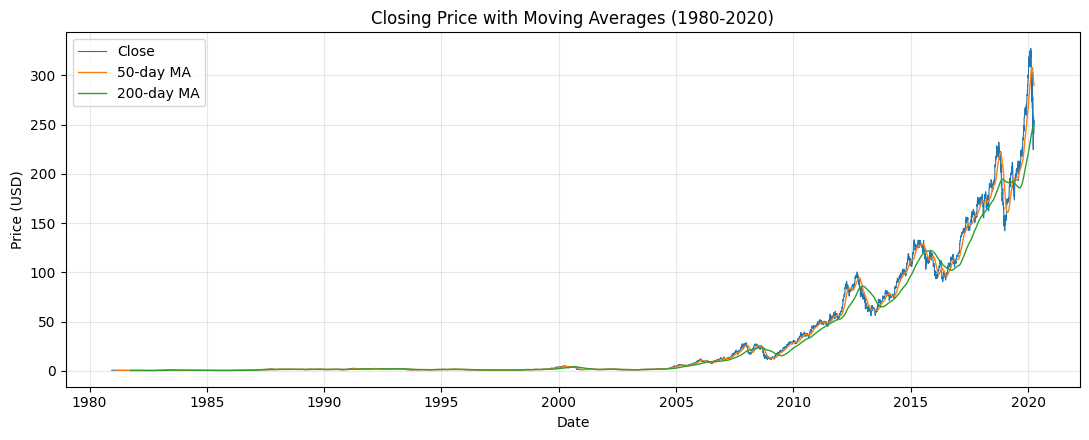

In [5]:
plt.figure(figsize=(11, 4.5))
plt.plot(df['Date'], df['Close'],  lw=0.8, label='Close')
plt.plot(df['Date'], df['MA50'],   lw=1.0, label='50-day MA')
plt.plot(df['Date'], df['MA200'],  lw=1.0, label='200-day MA')
plt.title('Closing Price with Moving Averages (1980-2020)')
plt.xlabel('Date'); plt.ylabel('Price (USD)')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figure_1_price_trend.png', dpi=130)
plt.show()

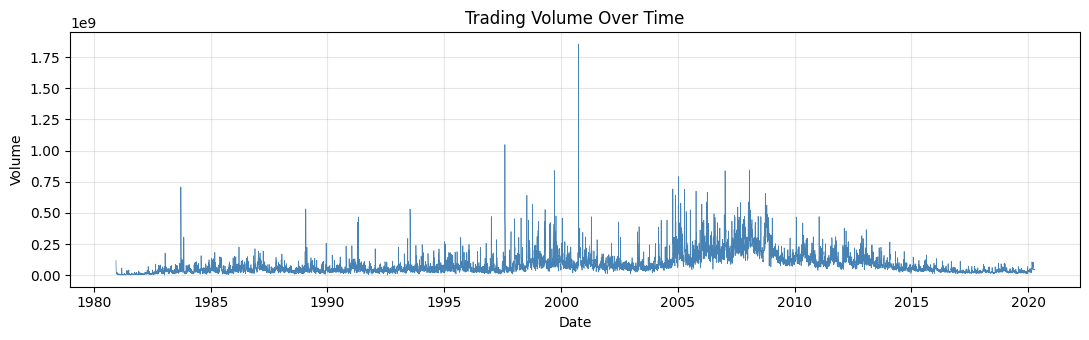

In [6]:
plt.figure(figsize=(11, 3.5))
plt.plot(df['Date'], df['Volume'], lw=0.5, color='steelblue')
plt.title('Trading Volume Over Time')
plt.xlabel('Date'); plt.ylabel('Volume')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figure_2_volume.png', dpi=130)
plt.show()

In [7]:
# Restrict to 2010 onward (the early years are at a completely different price scale)
df_model = df[df['Date'] >= '2010-01-01'].reset_index(drop=True)
features = ['Open', 'High', 'Low', 'Close', 'Volume']
data = df_model[features].values.astype('float32')

# Chronological split: 70% train, 15% validation, 15% test
n = len(data)
i_train, i_val = int(n * 0.70), int(n * 0.85)
train_raw = data[:i_train]
val_raw   = data[i_train:i_val]
test_raw  = data[i_val:]

print(f"Modelling window: {df_model['Date'].iloc[0].date()} to {df_model['Date'].iloc[-1].date()}")
print(f"  Training set  : {len(train_raw)} rows ({df_model['Date'].iloc[0].date()} to {df_model['Date'].iloc[i_train-1].date()})")
print(f"  Validation set: {len(val_raw)} rows ({df_model['Date'].iloc[i_train].date()} to {df_model['Date'].iloc[i_val-1].date()})")
print(f"  Test set      : {len(test_raw)} rows ({df_model['Date'].iloc[i_val].date()} to {df_model['Date'].iloc[-1].date()})")

Modelling window: 2010-01-04 to 2020-04-01
  Training set  : 1805 rows (2010-01-04 to 2017-03-06)
  Validation set: 387 rows (2017-03-07 to 2018-09-17)
  Test set      : 387 rows (2018-09-18 to 2020-04-01)


In [8]:
scaler_X = MinMaxScaler(); scaler_X.fit(train_raw)
scaler_y = MinMaxScaler(); scaler_y.fit(train_raw[:, 3:4])  # column 3 = Close

train_s = scaler_X.transform(train_raw)
val_s   = scaler_X.transform(val_raw)
test_s  = scaler_X.transform(test_raw)

print("Scaling complete. Feature ranges after scaling:")
print(f"  Train min/max: {train_s.min():.3f} / {train_s.max():.3f}")
print(f"  Val   min/max: {val_s.min():.3f} / {val_s.max():.3f}")
print(f"  Test  min/max: {test_s.min():.3f} / {test_s.max():.3f}")

Scaling complete. Feature ranges after scaling:
  Train min/max: 0.000 / 1.000
  Val   min/max: 0.002 / 1.796
  Test  min/max: -0.000 / 2.671


In [9]:
def make_sequences(arr, seq_len):
    """Turn a 2D array into sliding windows of length seq_len."""
    X, y = [], []
    for i in range(seq_len, len(arr)):
        X.append(arr[i-seq_len:i])
        y.append(arr[i, 3])   # column 3 = Close
    return np.array(X), np.array(y)

def make_split_sequences(seq_len):
    """Build sequences for train/val/test with boundary handling."""
    tr_X, tr_y = make_sequences(train_s, seq_len)
    val_arr  = np.vstack([train_s[-seq_len:], val_s])
    test_arr = np.vstack([val_s[-seq_len:], test_s])
    va_X, va_y = make_sequences(val_arr,  seq_len)
    te_X, te_y = make_sequences(test_arr, seq_len)
    return tr_X, tr_y, va_X, va_y, te_X, te_y

In [10]:
def build_model(cell_type, seq_len, n_features, units, dropout, n_layers=2):
    m = Sequential([Input(shape=(seq_len, n_features))])
    Layer = LSTM if cell_type == 'lstm' else GRU
    for k in range(n_layers):
        m.add(Layer(units, return_sequences=(k < n_layers - 1)))
        m.add(Dropout(dropout))
    m.add(Dense(1))
    m.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return m

In [11]:
def inv_close(y_scaled):
    return scaler_y.inverse_transform(np.array(y_scaled).reshape(-1, 1)).flatten()

def evaluate(y_true_s, y_pred_s):
    y_true = inv_close(y_true_s); y_pred = inv_close(y_pred_s)
    return {
        'MAE':  float(mean_absolute_error(y_true, y_pred)),
        'RMSE': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'MAPE': float(np.mean(np.abs((y_true - y_pred) / y_true)) * 100),
        'R2':   float(r2_score(y_true, y_pred)),
    }, y_true, y_pred

In [12]:
experiments = [
    ('M1_LSTM_30_50_0.2', 'lstm', 30, 50, 0.2),
    ('M2_LSTM_30_50_0.3', 'lstm', 30, 50, 0.3),
    ('M3_LSTM_30_64_0.2', 'lstm', 30, 64, 0.2),
    ('M4_LSTM_60_50_0.2', 'lstm', 60, 50, 0.2),
    ('M5_LSTM_60_64_0.3', 'lstm', 60, 64, 0.3),
    ('M6_GRU_30_50_0.2',  'gru',  30, 50, 0.2),
    ('M7_GRU_60_50_0.2',  'gru',  60, 50, 0.2),
    ('M8_GRU_60_64_0.3',  'gru',  60, 64, 0.3),
]

results = {}
histories = {}
val_preds = {}
test_preds = {}

for name, cell, seq_len, units, dropout in experiments:
    print(f"\n=== Training {name} (seq={seq_len}, units={units}, dropout={dropout}) ===")
    tr_X, tr_y, va_X, va_y, te_X, te_y = make_split_sequences(seq_len)
    model = build_model(cell, seq_len, tr_X.shape[2], units, dropout)
    param_count = int(model.count_params())

    es = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
    t0 = time.time()
    hist = model.fit(tr_X, tr_y, validation_data=(va_X, va_y),
                     epochs=15, batch_size=128, callbacks=[es], verbose=0)
    train_time = time.time() - t0

    val_pred  = model.predict(va_X, verbose=0).flatten()
    test_pred = model.predict(te_X, verbose=0).flatten()
    val_m,  val_yt,  val_yp  = evaluate(va_y, val_pred)
    test_m, test_yt, test_yp = evaluate(te_y, test_pred)

    results[name] = {
        'cell': cell.upper(), 'seq_len': seq_len, 'units': units, 'dropout': dropout,
        'params': param_count, 'epochs_trained': len(hist.history['loss']),
        'train_time_s': round(train_time, 1),
        'val_MAE':  val_m['MAE'],  'val_RMSE': val_m['RMSE'],
        'val_MAPE': val_m['MAPE'], 'val_R2':   val_m['R2'],
        'test_MAE':  test_m['MAE'],  'test_RMSE': test_m['RMSE'],
        'test_MAPE': test_m['MAPE'], 'test_R2':   test_m['R2'],
    }
    histories[name] = hist.history
    val_preds[name]  = {'y_true': val_yt,  'y_pred': val_yp}
    test_preds[name] = {'y_true': test_yt, 'y_pred': test_yp}

    print(f"  Validation: RMSE={val_m['RMSE']:.2f} MAE={val_m['MAE']:.2f} "
          f"MAPE={val_m['MAPE']:.2f}% R2={val_m['R2']:.3f}")
    print(f"  Test:       RMSE={test_m['RMSE']:.2f} MAE={test_m['MAE']:.2f} "
          f"MAPE={test_m['MAPE']:.2f}% R2={test_m['R2']:.3f}")
    print(f"  Parameters: {param_count:,}    Train time: {train_time:.1f}s    "
          f"Epochs run: {len(hist.history['loss'])}")

print("\n\nAll 8 models trained successfully.")


=== Training M1_LSTM_30_50_0.2 (seq=30, units=50, dropout=0.2) ===
  Validation: RMSE=17.59 MAE=14.14 MAPE=7.79% R2=0.279
  Test:       RMSE=52.40 MAE=42.49 MAPE=17.45% R2=-0.311
  Parameters: 31,451    Train time: 10.8s    Epochs run: 8

=== Training M2_LSTM_30_50_0.3 (seq=30, units=50, dropout=0.3) ===
  Validation: RMSE=20.43 MAE=16.97 MAPE=9.42% R2=0.028
  Test:       RMSE=57.03 MAE=47.23 MAPE=19.56% R2=-0.553
  Parameters: 31,451    Train time: 11.0s    Epochs run: 8

=== Training M3_LSTM_30_64_0.2 (seq=30, units=64, dropout=0.2) ===
  Validation: RMSE=9.72 MAE=7.34 MAPE=4.04% R2=0.780
  Test:       RMSE=32.60 MAE=24.59 MAPE=9.90% R2=0.493
  Parameters: 51,009    Train time: 22.5s    Epochs run: 15

=== Training M4_LSTM_60_50_0.2 (seq=60, units=50, dropout=0.2) ===
  Validation: RMSE=9.59 MAE=6.84 MAPE=3.72% R2=0.786
  Test:       RMSE=36.88 MAE=27.21 MAPE=10.85% R2=0.351
  Parameters: 31,451    Train time: 24.3s    Epochs run: 15

=== Training M5_LSTM_60_64_0.3 (seq=60, units=64

In [13]:
val_table = pd.DataFrame([
    {
        'Model': name, 'Cell': r['cell'], 'Seq': r['seq_len'],
        'Units': r['units'], 'Dropout': r['dropout'],
        'RMSE': round(r['val_RMSE'], 2), 'MAE': round(r['val_MAE'], 2),
        'MAPE (%)': round(r['val_MAPE'], 2), 'R²': round(r['val_R2'], 3),
        'Params': r['params'], 'Epochs': r['epochs_trained'],
        'Train time (s)': r['train_time_s'],
    }
    for name, r in results.items()
])
print("TABLE 1: Validation-set performance of the 8 configurations")
print("(This is used for model selection.)")
display(val_table)

TABLE 1: Validation-set performance of the 8 configurations
(This is used for model selection.)


,Model,Cell,Seq,Units,Dropout,RMSE,MAE,MAPE (%),R²,Params,Epochs,Train time (s)
0,M1_LSTM_30_50_0.2,LSTM,30,50,0.2,17.59,14.14,7.79,0.279,31451,8,10.8
1,M2_LSTM_30_50_0.3,LSTM,30,50,0.3,20.43,16.97,9.42,0.028,31451,8,11.0
2,M3_LSTM_30_64_0.2,LSTM,30,64,0.2,9.72,7.34,4.04,0.780,51009,15,22.5
3,M4_LSTM_60_50_0.2,LSTM,60,50,0.2,9.59,6.84,3.72,0.786,31451,15,24.3
4,M5_LSTM_60_64_0.3,LSTM,60,64,0.3,19.13,14.99,8.20,0.148,51009,6,17.6
5,M6_GRU_30_50_0.2,GRU,30,50,0.2,7.25,5.23,2.87,0.878,23901,7,10.6
6,M7_GRU_60_50_0.2,GRU,60,50,0.2,7.87,5.64,3.08,0.856,23901,7,19.7
7,M8_GRU_60_64_0.3,GRU,60,64,0.3,5.22,4.04,2.36,0.937,38657,6,23.4


In [14]:
best_name = min(results.keys(), key=lambda n: results[n]['val_RMSE'])
best = results[best_name]
print(f"Best model on validation set: {best_name}")
print(f"  Cell type   : {best['cell']}")
print(f"  Sequence    : {best['seq_len']} days")
print(f"  Units       : {best['units']}")
print(f"  Dropout     : {best['dropout']}")
print(f"  Parameters  : {best['params']:,}")
print(f"  Val RMSE    : {best['val_RMSE']:.2f}")

Best model on validation set: M8_GRU_60_64_0.3
  Cell type   : GRU
  Sequence    : 60 days
  Units       : 64
  Dropout     : 0.3
  Parameters  : 38,657
  Val RMSE    : 5.22


In [15]:
test_row = pd.DataFrame([{
    'Model': best_name, 'Cell': best['cell'], 'Seq': best['seq_len'],
    'Units': best['units'], 'Dropout': best['dropout'],
    'RMSE': round(best['test_RMSE'], 2), 'MAE': round(best['test_MAE'], 2),
    'MAPE (%)': round(best['test_MAPE'], 2), 'R²': round(best['test_R2'], 3),
}])
print(f"TABLE 2: Test-set performance of the selected model ({best_name})")
display(test_row)

TABLE 2: Test-set performance of the selected model (M8_GRU_60_64_0.3)


,Model,Cell,Seq,Units,Dropout,RMSE,MAE,MAPE (%),R²
0,M8_GRU_60_64_0.3,GRU,60,64,0.3,18.93,13.39,5.33,0.829


In [16]:
# Persistence baseline on the test period (in raw dollar prices, not scaled)
test_close  = test_raw[:, 3]   # column 3 = Close
actual_bl    = test_close[1:]
predicted_bl = test_close[:-1]

baseline_metrics = {
    'MAE':  float(mean_absolute_error(actual_bl, predicted_bl)),
    'RMSE': float(np.sqrt(mean_squared_error(actual_bl, predicted_bl))),
    'MAPE': float(np.mean(np.abs((actual_bl - predicted_bl) / actual_bl)) * 100),
    'R2':   float(r2_score(actual_bl, predicted_bl)),
}

print("Persistence baseline metrics on the test set:")
for k, v in baseline_metrics.items():
    print(f"  {k:5}: {v:.4f}")

Persistence baseline metrics on the test set:
  MAE  : 3.5498
  RMSE : 5.6462
  MAPE : 1.5946
  R2   : 0.9848


In [17]:
compare_table = pd.DataFrame([
    {
        'Model': 'Persistence baseline (tomorrow = today)',
        'RMSE': round(baseline_metrics['RMSE'], 2),
        'MAE':  round(baseline_metrics['MAE'], 2),
        'MAPE (%)': round(baseline_metrics['MAPE'], 2),
        'R²': round(baseline_metrics['R2'], 3),
    },
    {
        'Model': f'Selected neural model ({best_name})',
        'RMSE': round(best['test_RMSE'], 2),
        'MAE':  round(best['test_MAE'], 2),
        'MAPE (%)': round(best['test_MAPE'], 2),
        'R²': round(best['test_R2'], 3),
    }
])
print("TABLE 3: Selected model vs persistence baseline (both on the test set)")
display(compare_table)

TABLE 3: Selected model vs persistence baseline (both on the test set)


,Model,RMSE,MAE,MAPE (%),R²
0,Persistence baseline (tomorrow = today),5.65,3.55,1.59,0.985
1,Selected neural model (M8_GRU_60_64_0.3),18.93,13.39,5.33,0.829


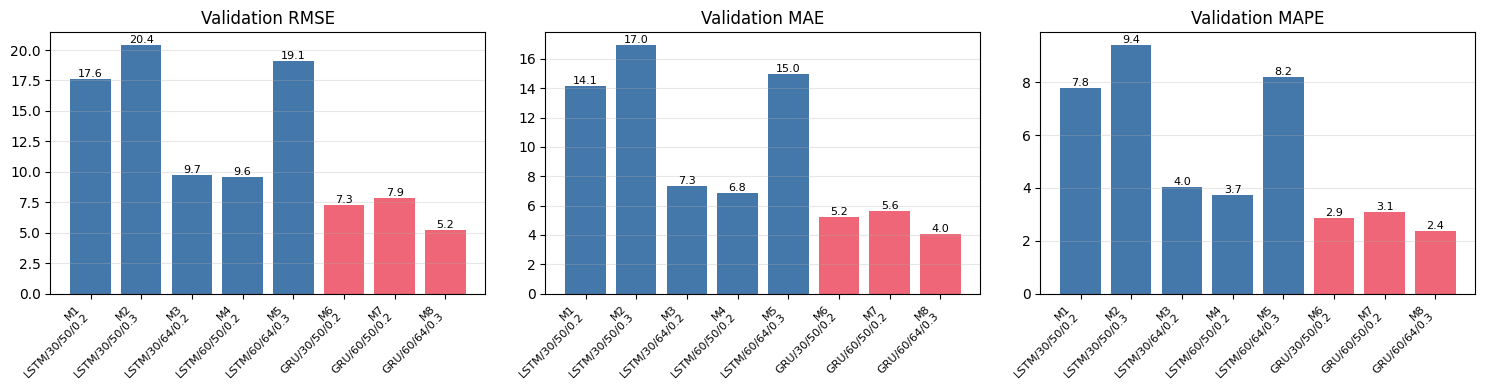

In [18]:
labels = list(results.keys())
short_labels = [n.split('_', 1)[0] + '\n' + n.split('_', 1)[1].replace('_', '/') for n in labels]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, m in zip(axes, ['RMSE', 'MAE', 'MAPE']):
    vals = [results[k][f'val_{m}'] for k in labels]
    colors = ['#4477AA' if results[k]['cell']=='LSTM' else '#EE6677' for k in labels]
    bars = ax.bar(range(len(labels)), vals, color=colors)
    ax.set_title(f'Validation {m}')
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(short_labels, rotation=45, ha='right', fontsize=8)
    ax.grid(alpha=0.3, axis='y')
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, v, f'{v:.1f}',
                ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('figure_3_model_comparison.png', dpi=130)
plt.show()

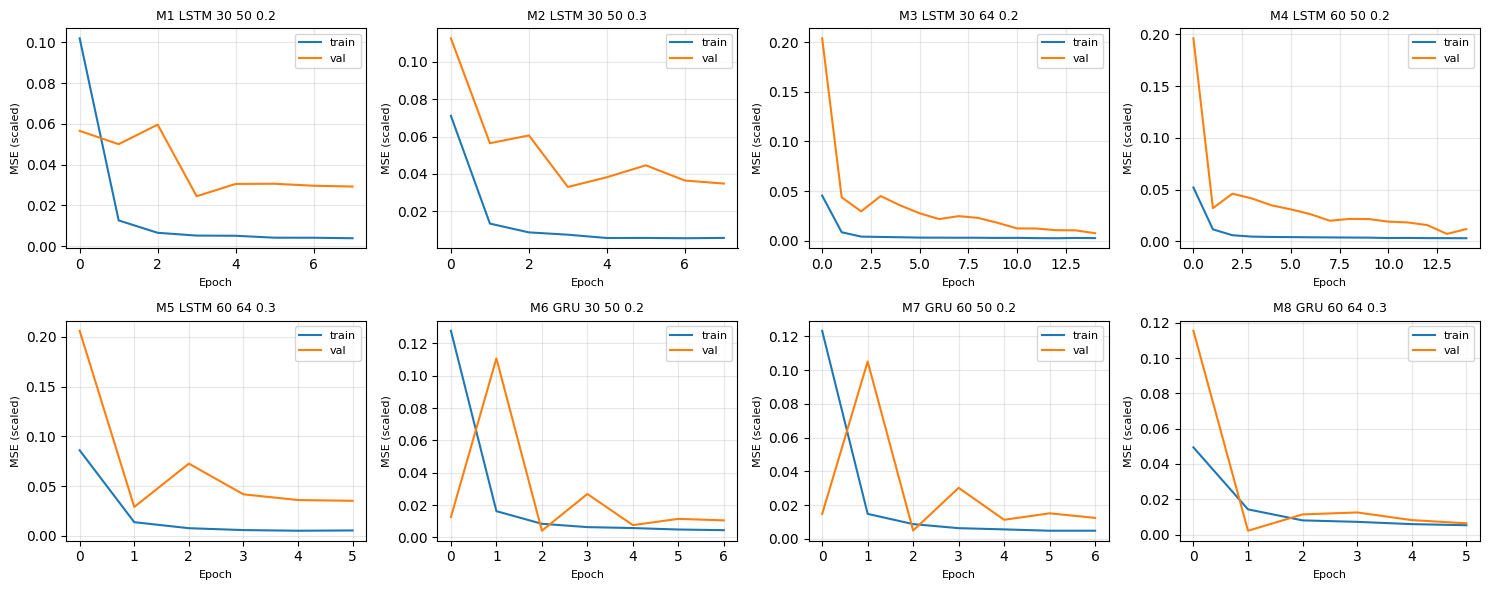

In [19]:
fig, axes = plt.subplots(2, 4, figsize=(15, 6))
for ax, name in zip(axes.flatten(), labels):
    h = histories[name]
    ax.plot(h['loss'], label='train')
    ax.plot(h['val_loss'], label='val')
    ax.set_title(name.replace('_', ' '), fontsize=9)
    ax.set_xlabel('Epoch', fontsize=8); ax.set_ylabel('MSE (scaled)', fontsize=8)
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figure_4_loss_curves.png', dpi=130)
plt.show()

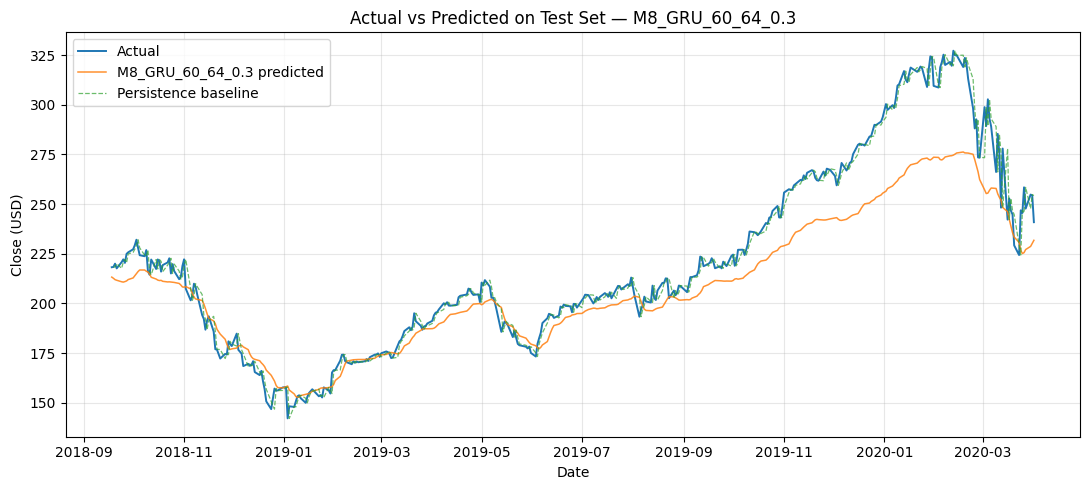

In [20]:
test_dates = df_model['Date'].iloc[i_val:].reset_index(drop=True)
p = test_preds[best_name]

fig, ax = plt.subplots(1, 1, figsize=(11, 5))
ax.plot(test_dates[:len(p['y_true'])], p['y_true'],
        label='Actual', lw=1.4)
ax.plot(test_dates[:len(p['y_pred'])], p['y_pred'],
        label=f'{best_name} predicted', lw=1.1, alpha=0.85)

# Overlay persistence baseline
bl_dates = test_dates.iloc[1:1+len(predicted_bl)].reset_index(drop=True)
ax.plot(bl_dates, predicted_bl,
        label='Persistence baseline', lw=0.9, alpha=0.7, linestyle='--')

ax.set_title(f'Actual vs Predicted on Test Set — {best_name}')
ax.set_xlabel('Date'); ax.set_ylabel('Close (USD)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figure_5_actual_vs_pred.png', dpi=130)
plt.show()

In [21]:
print("=" * 70)
print("SUMMARY — key numbers for the report")
print("=" * 70)

print(f"\nDataset: Apple Inc. (AAPL), {df_model['Date'].iloc[0].date()} to {df_model['Date'].iloc[-1].date()}")
print(f"Train / Val / Test split: {len(train_raw)} / {len(val_raw)} / {len(test_raw)} days")

print(f"\nSelected model (by validation RMSE): {best_name}")
print(f"  Configuration: {best['cell']}, seq={best['seq_len']}, units={best['units']}, dropout={best['dropout']}")
print(f"  Parameters   : {best['params']:,}")
print(f"  Val  RMSE    : {best['val_RMSE']:.2f}")
print(f"  Test RMSE    : {best['test_RMSE']:.2f}")
print(f"  Test MAE     : {best['test_MAE']:.2f}")
print(f"  Test MAPE    : {best['test_MAPE']:.2f}%")
print(f"  Test R²      : {best['test_R2']:.3f}")

print(f"\nPersistence baseline (test set):")
print(f"  RMSE : {baseline_metrics['RMSE']:.2f}")
print(f"  MAE  : {baseline_metrics['MAE']:.2f}")
print(f"  MAPE : {baseline_metrics['MAPE']:.2f}%")
print(f"  R²   : {baseline_metrics['R2']:.3f}")

# Save results to JSON for the record
with open('run_results.json', 'w') as f:
    json.dump({
        'results': results,
        'baseline': baseline_metrics,
        'best_model': best_name,
        'seed': SEED,
    }, f, indent=2, default=str)
print("\nAll numeric results saved to run_results.json")

SUMMARY — key numbers for the report

Dataset: Apple Inc. (AAPL), 2010-01-04 to 2020-04-01
Train / Val / Test split: 1805 / 387 / 387 days

Selected model (by validation RMSE): M8_GRU_60_64_0.3
  Configuration: GRU, seq=60, units=64, dropout=0.3
  Parameters   : 38,657
  Val  RMSE    : 5.22
  Test RMSE    : 18.93
  Test MAE     : 13.39
  Test MAPE    : 5.33%
  Test R²      : 0.829

Persistence baseline (test set):
  RMSE : 5.65
  MAE  : 3.55
  MAPE : 1.59%
  R²   : 0.985

All numeric results saved to run_results.json


In [22]:
from google.colab import files

for fname in [
    'figure_1_price_trend.png',
    'figure_2_volume.png',
    'figure_3_model_comparison.png',
    'figure_4_loss_curves.png',
    'figure_5_actual_vs_pred.png',
    'run_results.json',
]:
    files.download(fname)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>